# Failure Prediction

This notebook builds the first predictive maintenance classification models for FactoryMind AI.

The goal is to predict whether a machine will experience a failure using operating conditions and sensor-related features.

Main target:

- `Machine failure`

Candidate predictive features:

- `Type`
- `Air temperature [K]`
- `Process temperature [K]`
- `Rotational speed [rpm]`
- `Torque [Nm]`
- `Tool wear [min]`

Identifier columns and failure-mode labels are intentionally excluded to avoid noise and target leakage.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

In [4]:
feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[feature_columns]
y = df["Machine failure"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
y_train.value_counts(normalize=True) * 100

Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

In [7]:
y_test.value_counts(normalize=True) * 100

Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64

In [8]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [11]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [12]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Type','Air temperature [K]','Process temperature [K]', 'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of

In [13]:
y_pred = baseline_model.predict(X_test)

In [14]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9675
Precision: 0.6363636363636364
Recall   : 0.10294117647058823
F1 Score : 0.17721518987341772


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [19]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1928,    4],
       [  61,    7]])

In [20]:
LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [21]:
balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [22]:
balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

In [23]:
print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1 Score :", f1_score(y_test, y_pred_balanced))

print()
print(classification_report(y_test, y_pred_balanced))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy : 0.8245
Precision: 0.14177215189873418
Recall   : 0.8235294117647058
F1 Score : 0.24190064794816415

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000

Confusion Matrix:
[[1593  339]
 [  12   56]]


## Baseline vs Balanced Logistic Regression

The baseline logistic regression achieved high overall accuracy but detected only 7 of the 68 machine failures in the test set. Its failure recall was approximately 10.3%, demonstrating that accuracy alone is misleading for this highly imbalanced dataset.

Using `class_weight="balanced"` increased failure recall to approximately 82.4%, detecting 56 of the 68 failures and reducing false negatives from 61 to 12.

However, this improvement came at the cost of substantially more false positives and lower precision. The next modeling stage should therefore focus on maintaining high failure recall while reducing unnecessary false alarms.

## Model Comparison

After establishing the logistic regression baselines, we evaluate tree-based models that can capture nonlinear relationships and interactions between machine operating conditions.

In [25]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [26]:
random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

In [27]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print()
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.9795
Precision: 0.7142857142857143
Recall   : 0.6617647058823529
F1 Score : 0.6870229007633588

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.66      0.69        68

    accuracy                           0.98      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
[[1914   18]
 [  23   45]]


In [29]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

print()
print(classification_report(y_test, y_pred_gb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy : 0.9855
Precision: 0.8823529411764706
Recall   : 0.6617647058823529
F1 Score : 0.7563025210084033

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.66      0.76        68

    accuracy                           0.99      2000
   macro avg       0.94      0.83      0.87      2000
weighted avg       0.98      0.99      0.98      2000

Confusion Matrix:
[[1926    6]
 [  23   45]]


In [33]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [34]:
models = {
    "Balanced Logistic Regression": balanced_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results[name] = {
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    }

pd.DataFrame(cv_results).T.round(3)

,Precision,Recall,F1
Balanced Logistic Regression,0.137,0.804,0.235
Random Forest,0.717,0.624,0.666
Gradient Boosting,0.873,0.602,0.709


## Feature Engineering

Based on patterns identified during EDA, additional features are created to represent physically meaningful relationships between operating variables.

Candidate engineered features:

- Temperature difference
- Power proxy
- Mechanical strain proxy

Their contribution will be evaluated using the same cross-validation strategy as the original feature set.

In [36]:
X_engineered = X.copy()

X_engineered["Temperature difference"] = (
    X_engineered["Process temperature [K]"]
    - X_engineered["Air temperature [K]"]
)

X_engineered["Power proxy"] = (
    X_engineered["Torque [Nm]"]
    * X_engineered["Rotational speed [rpm]"]
)

X_engineered["Mechanical strain proxy"] = (
    X_engineered["Torque [Nm]"]
    * X_engineered["Tool wear [min]"]
)

In [37]:
X_engineered.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference,Power proxy,Mechanical strain proxy
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0


In [38]:
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
numerical_features_eng = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature difference",
    "Power proxy",
    "Mechanical strain proxy"
]

preprocessor_eng = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features_eng
        )
    ]
)

In [40]:
gradient_boosting_eng = Pipeline(
    steps=[
        ("preprocessor", preprocessor_eng),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

In [41]:
eng_cv_scores = cross_validate(
    gradient_boosting_eng,
    X_train_eng,
    y_train_eng,
    cv=cv,
    scoring=scoring
)

engineered_results = {
    "Precision": eng_cv_scores["test_precision"].mean(),
    "Recall": eng_cv_scores["test_recall"].mean(),
    "F1": eng_cv_scores["test_f1"].mean()
}

pd.Series(engineered_results).round(3)

Precision    0.966
Recall       0.827
F1           0.891
dtype: float64

In [42]:
feature_comparison = pd.DataFrame(
    {
        "Original Features": cv_results["Gradient Boosting"],
        "Engineered Features": engineered_results
    }
)

feature_comparison.round(3)

,Original Features,Engineered Features
Precision,0.873,0.966
Recall,0.602,0.827
F1,0.709,0.891


### Feature Ablation Study

To understand the individual contribution of each engineered feature, each feature is evaluated separately using the same Gradient Boosting model and 5-fold stratified cross-validation.

In [43]:
def evaluate_feature_set(feature_df, numerical_columns):
    X_train_temp, _, y_train_temp, _ = train_test_split(
        feature_df,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    temp_preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            ),
            (
                "numerical",
                StandardScaler(),
                numerical_columns
            )
        ]
    )

    temp_model = Pipeline(
        steps=[
            ("preprocessor", temp_preprocessor),
            (
                "classifier",
                GradientBoostingClassifier(random_state=42)
            )
        ]
    )

    scores = cross_validate(
        temp_model,
        X_train_temp,
        y_train_temp,
        cv=cv,
        scoring=scoring
    )

    return {
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    }

In [44]:
engineered_feature_names = [
    "Temperature difference",
    "Power proxy",
    "Mechanical strain proxy"
]

ablation_results = {}

for feature in engineered_feature_names:
    temp_features = X.copy()
    temp_numerical_features = numerical_features.copy()

    if feature == "Temperature difference":
        temp_features[feature] = (
            temp_features["Process temperature [K]"]
            - temp_features["Air temperature [K]"]
        )

    elif feature == "Power proxy":
        temp_features[feature] = (
            temp_features["Torque [Nm]"]
            * temp_features["Rotational speed [rpm]"]
        )

    elif feature == "Mechanical strain proxy":
        temp_features[feature] = (
            temp_features["Torque [Nm]"]
            * temp_features["Tool wear [min]"]
        )

    temp_numerical_features.append(feature)

    ablation_results[feature] = evaluate_feature_set(
        temp_features,
        temp_numerical_features
    )

In [46]:
ablation_table = pd.DataFrame(ablation_results).T

ablation_table.loc["Original Features"] = (
    cv_results["Gradient Boosting"]
)

ablation_table.loc["All Engineered Features"] = (
    engineered_results
)

ablation_table.round(3)

,Precision,Recall,F1
Temperature difference,0.899,0.675,0.769
Power proxy,0.930,0.675,0.781
Mechanical strain proxy,0.909,0.664,0.767
Original Features,0.873,0.602,0.709
All Engineered Features,0.966,0.827,0.891


## Model Explainability

Analyze which features contribute most to the Gradient Boosting model's failure predictions.

In [54]:
engineered_categorical_features = ["Type"]

engineered_numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature difference",
    "Power proxy",
    "Mechanical strain proxy"
]

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            engineered_categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            engineered_numerical_features
        )
    ]
)

final_model = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

final_model.fit(X_train_eng, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Type','Air temperature [K]','Process temperature [K]',..., 'Temperature difference','Power proxy','Mechanical strain proxy']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped.

In [55]:
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
9,numerical__Power proxy,0.276273
8,numerical__Temperature difference,0.266099
10,numerical__Mechanical strain proxy,0.249259
5,numerical__Rotational speed [rpm],0.107269
7,numerical__Tool wear [min],0.041718
1,categorical__Type_L,0.030836
6,numerical__Torque [Nm],0.011530
4,numerical__Process temperature [K],0.009224
3,numerical__Air temperature [K],0.004055
2,categorical__Type_M,0.002470


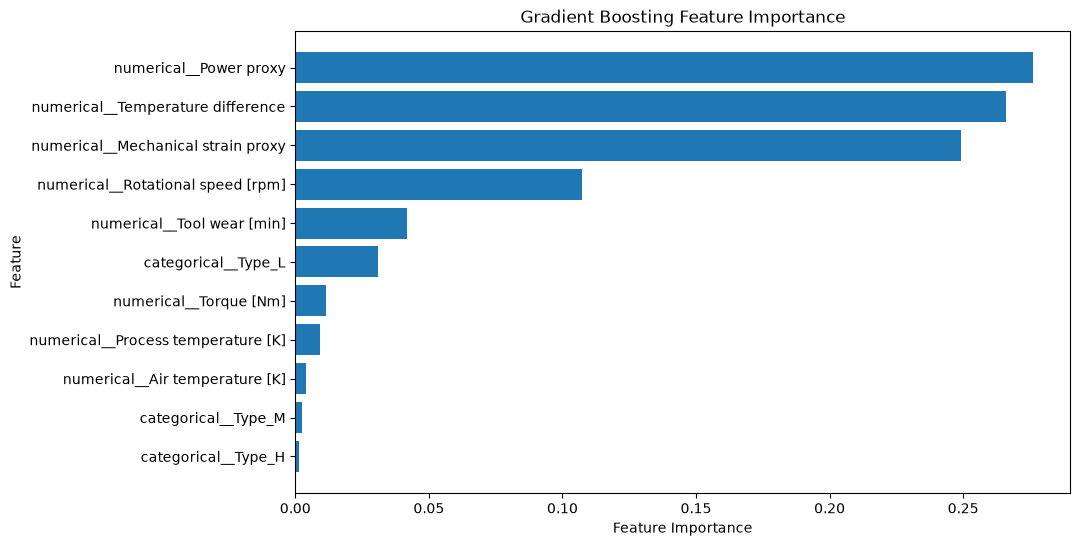

In [58]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()

plt.show()

## Final Model Evaluation

Evaluate the selected Gradient Boosting model with engineered features on the held-out test set.

In [59]:
X_test_eng = X_test.copy()

X_test_eng["Temperature difference"] = (
    X_test_eng["Process temperature [K]"]
    - X_test_eng["Air temperature [K]"]
)

X_test_eng["Power proxy"] = (
    X_test_eng["Rotational speed [rpm]"]
    * X_test_eng["Torque [Nm]"]
)

X_test_eng["Mechanical strain proxy"] = (
    X_test_eng["Torque [Nm]"]
    * X_test_eng["Tool wear [min]"]
)

In [60]:
final_pred = final_model.predict(X_test_eng)

print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Accuracy : 0.993
Precision: 1.0
Recall   : 0.7941176470588235
F1 Score : 0.8852459016393442

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       1.00      0.79      0.89        68

    accuracy                           0.99      2000
   macro avg       1.00      0.90      0.94      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix:
[[1932    0]
 [  14   54]]
